In [127]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# load the data
df_raw = pd.read_csv("luad_mskcc_2023_met_organotropism_clinical_data.tsv", sep='\t')
df_raw.columns = df_raw.columns.str.strip()

df = df_raw[df_raw['Group Number'].isin(['Group1', 'Group2'])]
target_cols = [
    'Ever Met to Site: CNS',
    'Ever Met to Site: Bone',
    'Ever Met to Site: Liver',
    'Ever Met to Site: Lung',
    'Ever Met to Site: Lymph Nodes',
    'Ever Met to Site: Pleura',
    'Ever Met to Site: Adrenal'
]
# drop missing features
percent_missing_per_feature = df.isnull().mean().sort_values(ascending=False)
drop_cols = percent_missing_per_feature[percent_missing_per_feature > .2].index.to_list()
df = df.drop(columns=drop_cols)

# drop rows with missing values
df = df.dropna()

#drop unknown rows from race category
df_clean = df[df['Race Category'] != 'Unknown']
df_clean


,Study ID,Patient ID,Sample ID,Adjuvant,Adjuvant Chemotherapy,Adjuvant Immunotherapy,Adjuvant Targeted,Adjuvant Therapy,Adjuvant XRT,Adrenal Met Status,...,Sample Class,Number of Samples Per Patient,Sample coverage,Sample Type,Sex,Somatic Status,TGF-Beta Pathway,TMB (nonsynonymous),TP53 Pathway,WNT Pathway
4,luad_mskcc_2023_met_organotropism,P-0000219,P-0000219-T01-IM3,Yes,Yes,No,No,Yes,Yes,0:RecurrenceFree,...,Tumor,1,1033.0,Primary,Female,Matched,Yes,4.436621,No,No
7,luad_mskcc_2023_met_organotropism,P-0000348,P-0000348-T01-IM3,Yes,No,No,No,Yes,Yes,0:RecurrenceFree,...,Tumor,1,689.0,Primary,Male,Matched,No,3.327466,Yes,No
37,luad_mskcc_2023_met_organotropism,P-0000867,P-0000867-T01-IM3,Yes,Yes,No,No,Yes,No,1:Recurrent,...,Tumor,1,364.0,Primary,Male,Matched,No,6.654932,Yes,No
61,luad_mskcc_2023_met_organotropism,P-0001241,P-0001241-T01-IM3,No,No,No,No,No,No,0:RecurrenceFree,...,Tumor,1,274.0,Primary,Female,Matched,No,4.436621,Yes,No
88,luad_mskcc_2023_met_organotropism,P-0001828,P-0001828-T01-IM3,No,No,No,No,No,No,0:RecurrenceFree,...,Tumor,1,546.0,Primary,Female,Matched,No,8.873242,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2034,luad_mskcc_2023_met_organotropism,P-0040055,P-0040055-T01-IM6,Yes,Yes,No,No,Yes,No,0:RecurrenceFree,...,Tumor,1,637.0,Primary,Female,Matched,Yes,5.188189,Yes,Yes
2041,luad_mskcc_2023_met_organotropism,P-0040473,P-0040473-T02-IM6,No,No,No,No,No,No,0:RecurrenceFree,...,Tumor,2,591.0,Primary,Female,Matched,No,10.376377,Yes,No
2046,luad_mskcc_2023_met_organotropism,P-0040655,P-0040655-T01-IM6,No,No,No,No,No,No,0:RecurrenceFree,...,Tumor,5,404.0,Primary,Female,Matched,No,7.782283,Yes,No
2066,luad_mskcc_2023_met_organotropism,P-0041217,P-0041217-T01-IM6,No,No,No,No,No,No,1:Recurrent,...,Tumor,1,651.0,Primary,Male,Matched,No,1.729396,No,No


In [139]:
# separate X and y
y = df_clean[target_cols]
metadata_cols = ['Study ID', 'Group Number', 'Samples used in Matched Analysis (Group 5)', 'Group Assignment for Primary Samples']
potential_leak_cols = ['Death', 'Overall Survival (Months)', 'Overall Survival Status', 'Primary Tumor Site', 'Cancer Type', 'Cancer Type Detailed', 'Oncotree Code', 'Institute Source',
                       'Post Sample Chemotherapy', 'Post Sample Immunotherapy', 'Post Sample Targeted', 'Post Sample Tx', 'Post Sample XRT',
                       'Metastatic Burden', 'Pleura Met Status', 'Adrenal Met Status', 'LN Met Status','Lung Met Status', 'Liver Met Status', 'CNS Met Status', 'Bone Met Status',
                       'HIPPO Pathway', 'MYC Pathway', 'NOTCH Pathway', 'NRF2 Pathway', 'PI3K Pathway', 'RTK- RAS Pathway', 'TGF-Beta Pathway', 'TP53 Pathway', 'WNT Pathway',
                        'Adjuvant Targeted', 'Adjuvant Therapy', 'Adjuvant Immunotherapy', 'Adjuvant Chemotherapy', 'Adjuvant XRT', 
                       'Neoadjuvant Immunotherapy', 'Neoadjuvant Chemotherapy', 'Neoadjuvant XRT', 'Neoadjuvant Targeted']


# drop all columns that are metadata and can cause potential leakage, and separate the target from the features
X = df_clean.drop(columns=target_cols + metadata_cols + potential_leak_cols)

# drop any column with one unique value, does not contribute to model
X = X.loc[:, X.nunique() > 1] 

cols = ['Patient ID', 'Sample ID', 'Gene Panel'] + [col for col in X.columns if col not in ['Patient ID', 'Sample ID', 'Gene Panel']]
X = X[cols]
X


,Patient ID,Sample ID,Gene Panel,Adjuvant,Age at Surgery/Biopsy,Cell Cycle,Tobacco History,Clinical Stage,FGA,Fraction Genome Altered,...,Pre Sample Targeted,Pre Sample Tx,Pre Sample XRT,Pathologic Stage,Purity,Race Category,Number of Samples Per Patient,Sample coverage,Sex,TMB (nonsynonymous)
4,P-0000219,P-0000219-T01-IM3,IMPACT341,Yes,52.917808,No,Ever,Stage I,0.199022,0.0001,...,No,No,No,Stage III,0.348728,White,1,1033.0,Female,4.436621
7,P-0000348,P-0000348-T01-IM3,IMPACT341,Yes,65.087671,No,Never,Stage III,0.724551,0.1428,...,No,Yes,No,Stage III,0.369512,White,1,689.0,Male,3.327466
37,P-0000867,P-0000867-T01-IM3,IMPACT341,Yes,64.947945,Yes,Ever,Stage I,0.701267,0.3039,...,No,No,No,Stage II,0.320492,Asian,1,364.0,Male,6.654932
61,P-0001241,P-0001241-T01-IM3,IMPACT341,No,83.178082,Yes,Never,Stage I,0.930460,0.3672,...,No,No,No,Stage II,0.556694,White,1,274.0,Female,4.436621
88,P-0001828,P-0001828-T01-IM3,IMPACT341,No,75.008219,No,Ever,Stage II,0.412422,0.1920,...,No,Yes,No,Stage I,0.374035,White,1,546.0,Female,8.873242
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2034,P-0040055,P-0040055-T01-IM6,IMPACT468,Yes,62.764384,No,Ever,Stage I,0.946808,0.4476,...,No,No,No,Stage II,0.353128,White,1,637.0,Female,5.188189
2041,P-0040473,P-0040473-T02-IM6,IMPACT468,No,70.597260,No,Ever,Stage I,0.253612,0.1807,...,No,No,No,Stage I,0.484608,White,2,591.0,Female,10.376377
2046,P-0040655,P-0040655-T01-IM6,IMPACT468,No,51.293151,No,Ever,Stage III,0.313980,0.0701,...,No,Yes,Yes,Stage II,0.322383,White,5,404.0,Female,7.782283
2066,P-0041217,P-0041217-T01-IM6,IMPACT468,No,71.747945,No,Never,Stage II,0.119257,0.0023,...,No,No,No,Stage III,0.300000,White,1,651.0,Male,1.729396


In [140]:
# encode features using one hot encoding
one_hot = ['Race Category', 'Sex', 'Tobacco History', 
           'Predominant Histologic Subtype','Pre Sample Immunotherapy', 'Pre Sample Targeted', 'Pre Sample Tx', 'Pre Sample XRT', 'Pre Sample Chemotherapy', 
           'Adjuvant', 'Neoadjuvant','Cell Cycle', 'MSI Type', 'At Least 2 Years Follow Up']
X_ENCODED= pd.get_dummies(X, columns=one_hot, drop_first=True)

# clinical stage and pathological stage's ordinal values may have clinical meaning. 
# We could go one hot encoding as well,
# but we choose to preserve the ordinal information
X_ENCODED['Clinical Stage'] = X_ENCODED['Clinical Stage'].map({'Stage I': 1, 'Stage II': 2, 'Stage III': 3, 'Stage IV': 4})
X_ENCODED['Pathologic Stage'] = X_ENCODED['Pathologic Stage'].map({'Stage I': 1, 'Stage II': 2, 'Stage III': 3})
X_ENCODED


,Patient ID,Sample ID,Gene Panel,Age at Surgery/Biopsy,Clinical Stage,FGA,Fraction Genome Altered,Is WGD,MSI Score,Mutation Count,...,Pre Sample Tx_Yes,Pre Sample XRT_Yes,Pre Sample Chemotherapy_Yes,Adjuvant_Yes,Neoadjuvant_Yes,Cell Cycle_Yes,MSI Type_Indeterminate,MSI Type_Instable,MSI Type_Stable,At Least 2 Years Follow Up_Yes
4,P-0000219,P-0000219-T01-IM3,IMPACT341,52.917808,1,0.199022,0.0001,0,0.08,4.0,...,False,False,False,True,False,False,False,False,True,True
7,P-0000348,P-0000348-T01-IM3,IMPACT341,65.087671,3,0.724551,0.1428,1,0.90,3.0,...,True,False,True,True,True,False,False,False,True,False
37,P-0000867,P-0000867-T01-IM3,IMPACT341,64.947945,1,0.701267,0.3039,1,0.08,6.0,...,False,False,False,True,False,True,False,False,True,True
61,P-0001241,P-0001241-T01-IM3,IMPACT341,83.178082,1,0.930460,0.3672,1,4.39,4.0,...,False,False,False,False,False,True,True,False,False,True
88,P-0001828,P-0001828-T01-IM3,IMPACT341,75.008219,2,0.412422,0.1920,1,0.00,8.0,...,True,False,True,False,True,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2034,P-0040055,P-0040055-T01-IM6,IMPACT468,62.764384,1,0.946808,0.4476,1,0.31,6.0,...,False,False,False,True,False,False,False,False,True,False
2041,P-0040473,P-0040473-T02-IM6,IMPACT468,70.597260,1,0.253612,0.1807,0,0.43,12.0,...,False,False,False,False,False,False,False,False,True,True
2046,P-0040655,P-0040655-T01-IM6,IMPACT468,51.293151,3,0.313980,0.0701,0,0.00,9.0,...,True,True,True,False,True,False,False,False,True,False
2066,P-0041217,P-0041217-T01-IM6,IMPACT468,71.747945,2,0.119257,0.0023,0,0.00,2.0,...,False,False,False,False,False,False,False,False,True,False


In [141]:
#save to csv
y.to_csv('y.csv', index=False)
X.to_csv('X_clinical.csv', index=False)


0


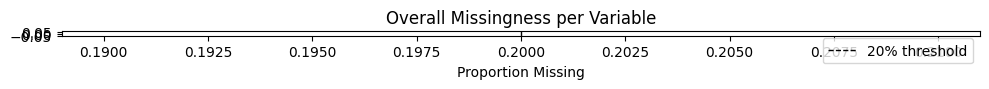

In [130]:
def plot_missing_overall(df, threshold=0.05):
    miss = df.isnull().mean().sort_values(ascending=False)
    miss = miss[miss > 0]  # only variables with any missingness
    print(len(miss))

    fig, ax = plt.subplots(figsize=(10, len(miss) * 0.35 + 1))
    colors = ['tomato' if v > threshold else 'steelblue' for v in miss]
    ax.barh(miss.index, miss.values, color=colors)
    ax.axvline(threshold, color='black', linestyle='--', linewidth=1, label=f'{int(threshold*100)}% threshold')
    ax.set_xlabel('Proportion Missing')
    ax.set_title('Overall Missingness per Variable')
    ax.legend()
    plt.tight_layout()
    plt.savefig('missing_overall.png', dpi=150)
    plt.show()

plot_missing_overall(df, threshold=0.2)
